In [ ]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)  # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


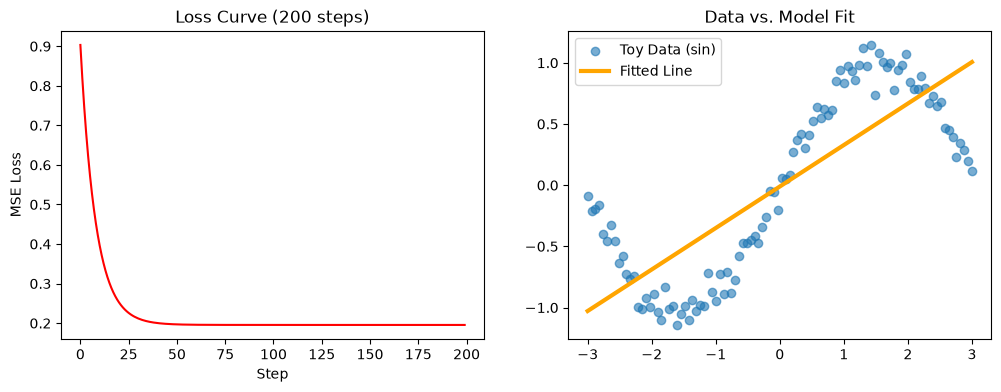

In [ ]:
## Part 1.1

# 1. Generate the toy data
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)

# 2. Initialise w and b to small random values
w = np.random.randn() * 0.1
b = np.random.randn() * 0.1
lr = 0.01
losses = []

# 3. Implement ONE gradient-descent step by hand, looped
for i in range(200):
    y_hat = w * x + b
    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))

    w -= lr * dw
    b -= lr * db

# 4. Plot the loss curve and the fitted line
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(losses, color="red")
ax1.set_title("Loss Curve (200 steps)")
ax1.set_xlabel("Step")
ax1.set_ylabel("MSE Loss")

ax2.scatter(x, y, label="Toy Data (sin)", alpha=0.6)
ax2.plot(x, w * x + b, color="orange", linewidth=3, label="Fitted Line")
ax2.set_title("Data vs. Model Fit")
ax2.legend()

plt.show()

![LossFuncDerivative](LossFunction_Derivative.png)


2. There is severe underfitting. A single neuron with no activation function calculates a purely linear combination. Mathematically, a straight line can never capture the periodic, non-linear carvature of a sine wave, regardless of how many epochs you train it for.


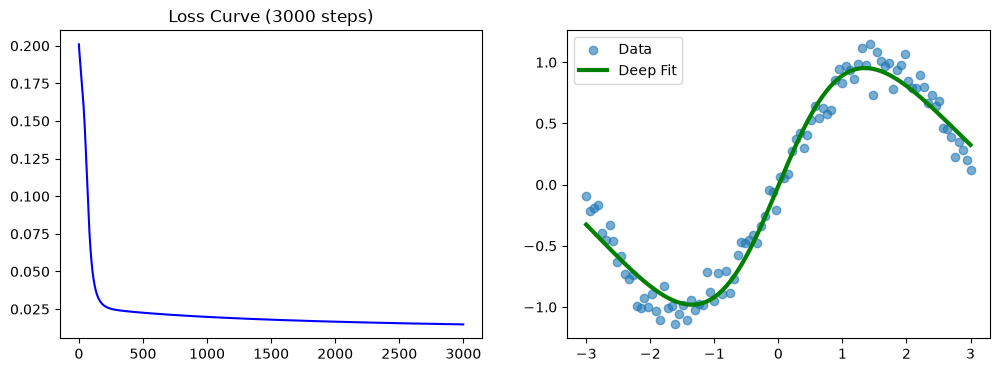

In [ ]:
##Part 1.2
# # 1. Initialise parameters
W1 = np.random.randn(1, 8) * 0.5
b1 = np.zeros((8,))
W2 = np.random.randn(8, 1) * 0.5
b2 = np.zeros((1,))

# Reshape data for matrix multiplication
x_mat = x.reshape(-1, 1)
y_mat = y.reshape(-1, 1)
lr = 0.05
losses = []

# 2 & 3. Forward pass, Backward pass, and Updates
for i in range(3000):
    # Forward Pass
    z1 = x_mat @ W1 + b1
    h = np.tanh(z1)
    y_hat = h @ W2 + b2

    loss = np.mean((y_hat - y_mat) ** 2)
    losses.append(loss)

    # Backward Pass
    d_yhat = 2 * (y_hat - y_mat) / len(y_mat)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)

    dh = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)
    dW1 = x_mat.T @ dz1
    db1 = dz1.sum(axis=0)

    # Update parameters
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

# 4. Plot the loss curve and the final fit
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(losses, color="blue")
ax1.set_title("Loss Curve (3000 steps)")

ax2.scatter(x, y, label="Data", alpha=0.6)
ax2.plot(x, y_hat, color="green", linewidth=3, label="Deep Fit")
ax2.legend()
plt.show()

1.Why Linear layers collapse:
if you remove the tanh activatio, the forward pass becomes ^y = (xw1 + b1)w2 +b2. by expanding this, it becomes : ^y = x(w1w2) +(b1w2+b2). Let W(new) = w1w2 and b(new) = b1w2 + b2. The equation simplifies perfectly to ^y = xw(new) + b(new), which is just a single linear tranformation.

2.The role of the 8 hidden neurons:
Each of the 8 neurons learns to represent a different bounded tanh "s-curve" located at different segments along the x-axis. The final output layer linearly combines these 8 separate curves to approximate the complex, non-linear shape of the sine wave

3. What is backpropagation?
   Backpropagation is an algorithm that uses the calculus chain rule to efficiently calculate the gradient of the loss function with respect to every single weight and bias in the neural network, moving backward from the output layer to the input layer.


C:\Users\Prince\AppData\Local\Temp\ipykernel_1772\3907222327.py:16: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y_mat) ** 2)
C:\Users\Prince\AppData\Local\Temp\ipykernel_1772\3907222327.py:23: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ W2.T
C:\Users\Prince\AppData\Local\Temp\ipykernel_1772\3907222327.py:24: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)


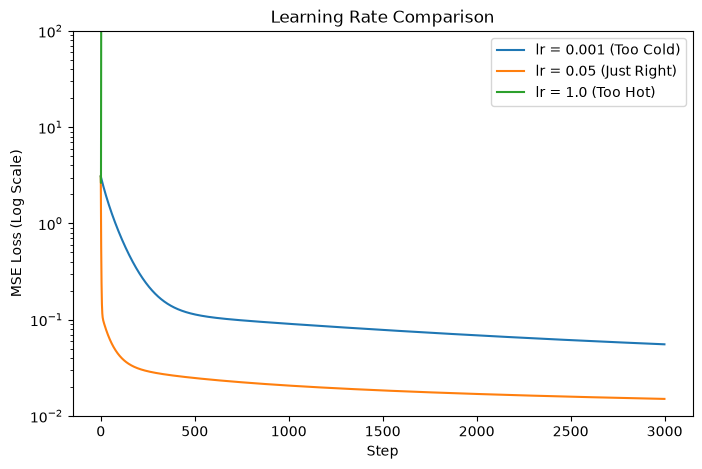

In [ ]:
## Part 1.3


def train_toy(lr, steps=3000):
    np.random.seed(42)  # Ensure fair comparison
    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.zeros((8,))
    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.zeros((1,))

    losses = []  ## Set to record losses
    for _ in range(steps):
        # Forward
        z1 = x_mat @ W1 + b1
        h = np.tanh(z1)
        y_hat = h @ W2 + b2
        loss = np.mean((y_hat - y_mat) ** 2)
        losses.append(loss)

        # Backward
        d_yhat = 2 * (y_hat - y_mat) / len(y_mat)
        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0)
        dh = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)
        dW1 = x_mat.T @ dz1
        db1 = dz1.sum(axis=0)

        # Update
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

    return losses


losses_slow = train_toy(0.001)
losses_good = train_toy(0.05)
losses_fast = train_toy(1.0)

plt.figure(figsize=(8, 5))
plt.plot(losses_slow, label="lr = 0.001 (Too Cold)")
plt.plot(losses_good, label="lr = 0.05 (Just Right)")
plt.plot(losses_fast, label="lr = 1.0 (Too Hot)")
plt.yscale("log")
plt.ylabel("MSE Loss (Log Scale)")
plt.xlabel("Step")
plt.title("Learning Rate Comparison")
plt.ylim(1e-2, 100)
plt.legend()
plt.show()

c:\Users\Prince\Desktop\Sup_Unsup_Learning\.venv\Lib\site-packages\numpy_core_methods.py:132: RuntimeWarning: overflow encountered in reduce
ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
C:\Users\Prince\AppData\Local\Temp\ipykernel_1772\443768776.py:16: RuntimeWarning: overflow encountered in square
loss = np.mean((y_hat - y_mat) ** 2)
C:\Users\Prince\AppData\Local\Temp\ipykernel_1772\443768776.py:23: RuntimeWarning: overflow encountered in matmul
dh = d_yhat @ W2.T
C:\Users\Prince\AppData\Local\Temp\ipykernel_1772\443768776.py:24: RuntimeWarning: invalid value encountered in multiply
dz1 = dh \* (1 - np.tanh(z1) ** 2)
c:\Users\Prince\Desktop\Sup_Unsup_Learning\.venv\Lib\site-packages\matplotlib\scale.py:375: RuntimeWarning: overflow encountered in exp
return np.exp(values \* np.log(self.base))

Student Reasoning - Learning Rate:
0.001 is Too cold: The Loss drops very slowly. The steps taken down the gradient are so tiny that the models fails to converge within the 3000 epochs

0.05 is Just Right: The loss drops rapidly and smooths out, finding the local minimum efficiently without overshooting.
0.1 is considered too hot: Thge curve oscillates widely or explodes. The step sizes are so large that the optimizer continuously overshoots the minimum of the loss valley, bouncing back and forth up the sides instead of settling at the bottom.
